## Import packages

In [41]:
import pandas as pd
import re
import html
import contractions
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

from gensim.models import Word2Vec

## Load Data

In [2]:
data = pd.read_csv('shortened_dataset.csv')
to_predict = pd.read_csv('test_scrape.csv')

descs = data['description']

## Pre-processing Function

In [3]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def text_preprocessor(text):
    # format text
    text = html.unescape(text)

    # expand contractions
    text = contractions.fix(text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords + lemmatize + words longer than 2 chars
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return tokens

## Vectorization

In [4]:
tokenized_corpus = [text_preprocessor(doc) for doc in descs]

processed_corpus = [
    " ".join(tokens)
    for tokens in tokenized_corpus
]

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

tfidf_vectorizer.fit(processed_corpus)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(processed_corpus),
    columns=tfidf_vectorizer.get_feature_names_out(),
)
df_tfidf

,0,00,000,1,10,100,1000,1001,101,101st,...,œã,œå,œæ,œç,œé,šã,šå,žã,ƒã,ˆã
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0.076424,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dimentionality Reduction

In [6]:
from sklearn.decomposition import TruncatedSVD

from matplotlib import pyplot as plt

In [7]:
svd = TruncatedSVD(n_components=df_tfidf.shape[1])
svd.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",11980
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [8]:
energy = svd.singular_values_**2
energy_ratio = energy / energy.sum()
energy_ratio_cumsum = energy_ratio.cumsum()

Explained variance at 3451 SVs: 0.90


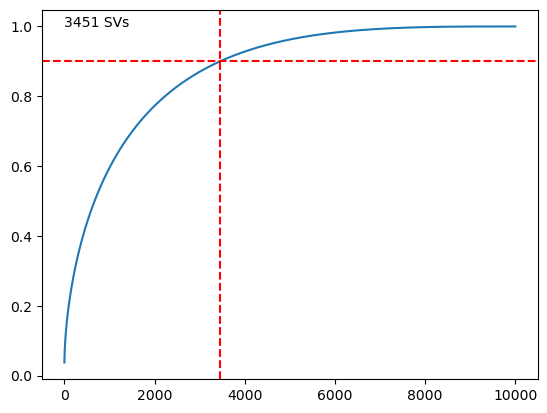

In [9]:
plt.plot([i for i in range(1,len(energy_ratio_cumsum)+1)], energy_ratio_cumsum)
plt.axhline(0.9, color='r', linestyle='--')

thresh = 0
for i in range(len(energy_ratio_cumsum)):
    if energy_ratio_cumsum[i] >= 0.9:
        plt.axvline(i+1, color='r', linestyle='--')
        plt.text(0, 1, f'{i+1} SVs')
        thresh = i+1
        print(f"Explained variance at {i+1} SVs: {energy_ratio_cumsum[i]:.2f}")
        break

In [10]:
W = pd.DataFrame(svd.components_, columns=df_tfidf.columns,
                 index=[f'SV {i+1}' for i in range(df_tfidf.shape[0])])
semantic_vectors = pd.DataFrame(svd.transform(df_tfidf), columns=W.index)
term_topic_matrix = pd.DataFrame(
    svd.components_.T,
    index=df_tfidf.columns,
    columns=[f'SV {i+1}' for i in range(df_tfidf.shape[0])]
)

In [11]:
def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')

    return fig, ax

(<Figure size 800x600 with 1 Axes>, <Axes: xlabel='Weight', ylabel='Term'>)

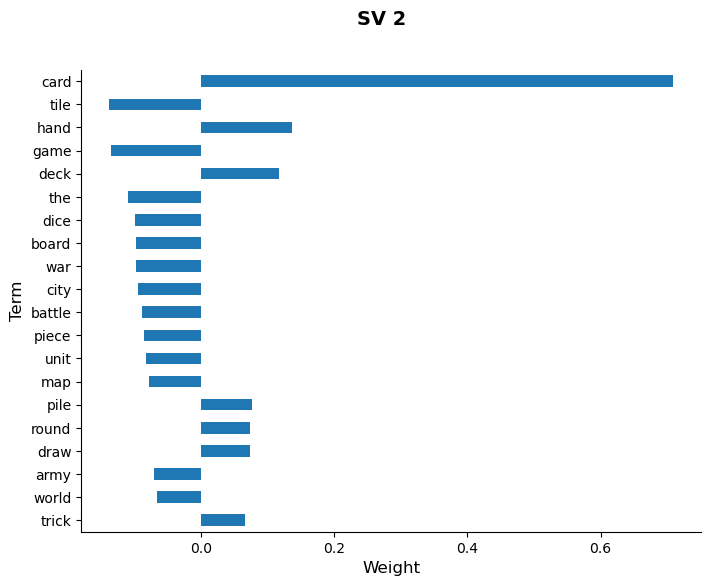

In [12]:
plot_topic_vector(term_topic_matrix, 'SV 2')

## ML Model

Current variables and functions:

`semantic_vectors`: X of model

`y`: target, average review score

`tfidf_vectorizer`: vectorizer fit on data. use this to transform predictions

`svd`: svd object fit on data. use this to transform predictions post tfidf

`text_preprocessor(text)`: preprocess predictions here

### KNN

In [13]:
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split

In [89]:
X = semantic_vectors.iloc[:, :thresh]
y = data['Average']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [16]:
reg = KNeighborsRegressor(n_neighbors=5)
reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
reg.predict(X_test)

array([6.472, 6.234, 6.772, ..., 6.206, 7.434, 6.89 ], shape=(2500,))

In [18]:
reg.score(X_test, y_test)

0.2041244206978058

In [19]:
trains = pd.DataFrame()
tests = pd.DataFrame()

for seedN in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seedN)
    train_acc = []
    test_acc = []
    neighbors = range(1,50)
    for n in neighbors:
        reg = KNeighborsRegressor(n_neighbors=n)
        reg.fit(X_train, y_train)
        train_acc.append(reg.score(X_train, y_train))
        test_acc.append(reg.score(X_test, y_test))
    trains[seedN] = train_acc
    tests[seedN] = test_acc

In [64]:
import pylab as plot

def plot_hyperparameter_tuning(
        hyperparameter,
        trains,
        tests,
        hparam_name: str,
        logscale: bool=False
    ):
    fig = plt.figure(figsize=(15, 6))
    if logscale:
        plt.xscale('log')
    params = {'legend.fontsize': 15, 'legend.handlelength': 2}
    plot.rcParams.update(params)
    
    plt.errorbar(hyperparameter, trains.mean(axis=1),
                 yerr=trains.std(axis=1), label="training accuracy", color='blue', marker='o', linestyle='dashed', markersize=15)
    plt.errorbar(hyperparameter, tests.mean(axis=1),
                 yerr=tests.std(axis=1), label="test accuracy", color='red', marker='^', linestyle='-', markersize=15)
    plt.ylabel("Accuracy", fontsize=15)
    plt.xlabel(hparam_name,fontsize=15)
    plt.legend()
    pass

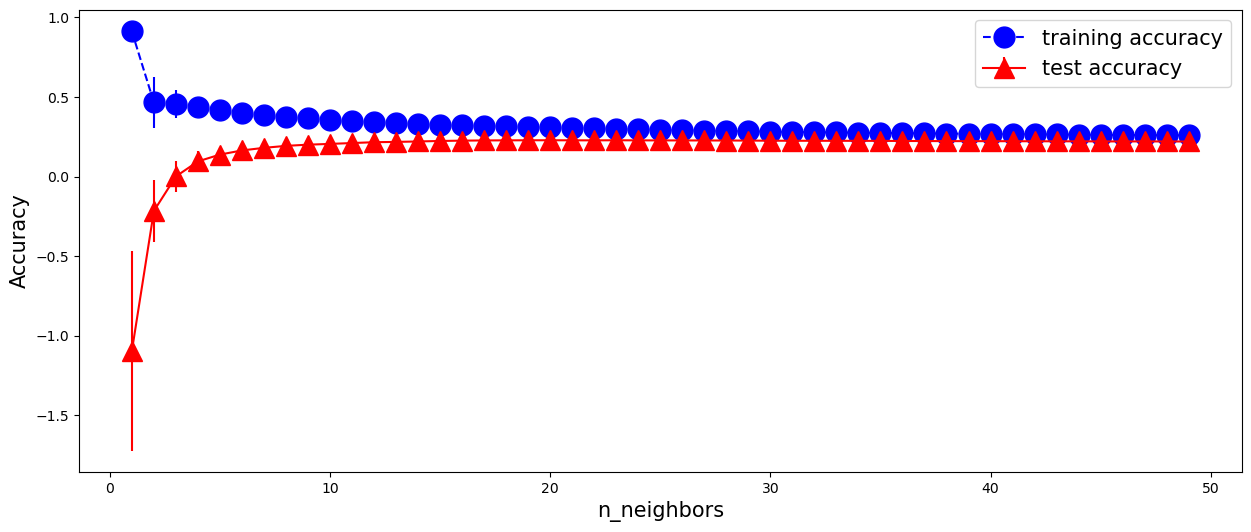

In [66]:
plot_hyperparameter_tuning(neighbors, trains, tests, 'n_neighbors')

clearly this shit doesnt fucking work

In [38]:
model_evaluation

,model,best_hyperparameter,train_accuracy,test_accuracy
0,knn,19,0.308663,0.228143


In [106]:
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso

In [56]:
No_Trials=10

all_training = pd.DataFrame()
all_test = pd.DataFrame()


for seedN in range(1,No_Trials):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seedN)
    training_accuracy = []
    test_accuracy = []
    alpha_parameter = [1e-5, 1e-4, 1e-3, 7e-3, 1e-2, 5e-2, 0.1, 0.2,0.4, 0.75, 1, 1.5, 3, 10, 20, 100, 500] #Tuning Parameters

    for alpha_run in alpha_parameter:
        reg = Lasso(alpha=alpha_run, max_iter=100000) # Define here wether Lasso or Ridge
        reg.fit(X_train, y_train) #build the model
        training_accuracy.append(reg.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(reg.score(X_test, y_test)) # record generalization accuracy
    all_training[seedN]=training_accuracy
    all_test[seedN] = test_accuracy

print("Best Accuracy = %f" %np.max(all_test.mean(axis=1)))
print("With \alpha given by %f" %alpha_parameter[np.argmax(all_test.mean(axis=1))])

Best Accuracy = 0.344931
With lpha given by 0.000100


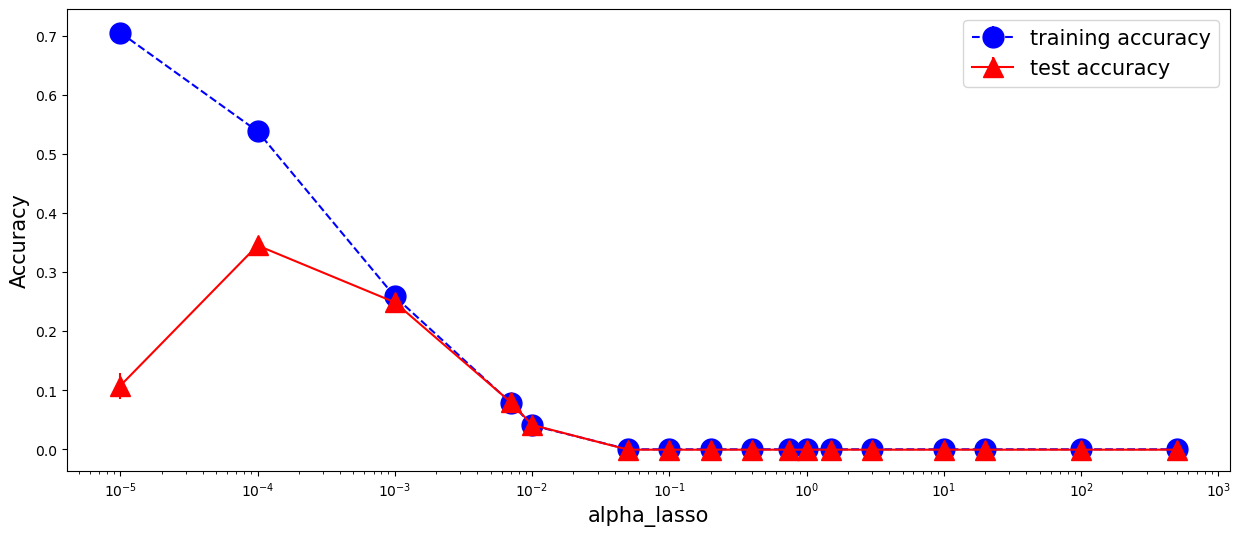

In [65]:
plot_hyperparameter_tuning(alpha_parameter, all_training, all_test, 'alpha_lasso', True)

# Classification

In [ ]:
from math import floor

In [164]:
def mapper_five_cats(x):
    return max(1, floor(x)//2)

def mapper_three_cats(x):
    if 0 <= x < 5:
        return 0
    elif 5 <= x < 8:
        return 1
    return 2

In [142]:
y_cat = y.apply(mapper)

In [92]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
lahat_training_knn = pd.DataFrame()
lahat_test_knn = pd.DataFrame()

for seedN in range(1, 10):
    X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.25, random_state=seedN)

    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50)

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train))
        test_accuracy.append(clf.score(X_test, y_test))

    lahat_training_knn[seedN] = training_accuracy
    lahat_test_knn[seedN] = test_accuracy

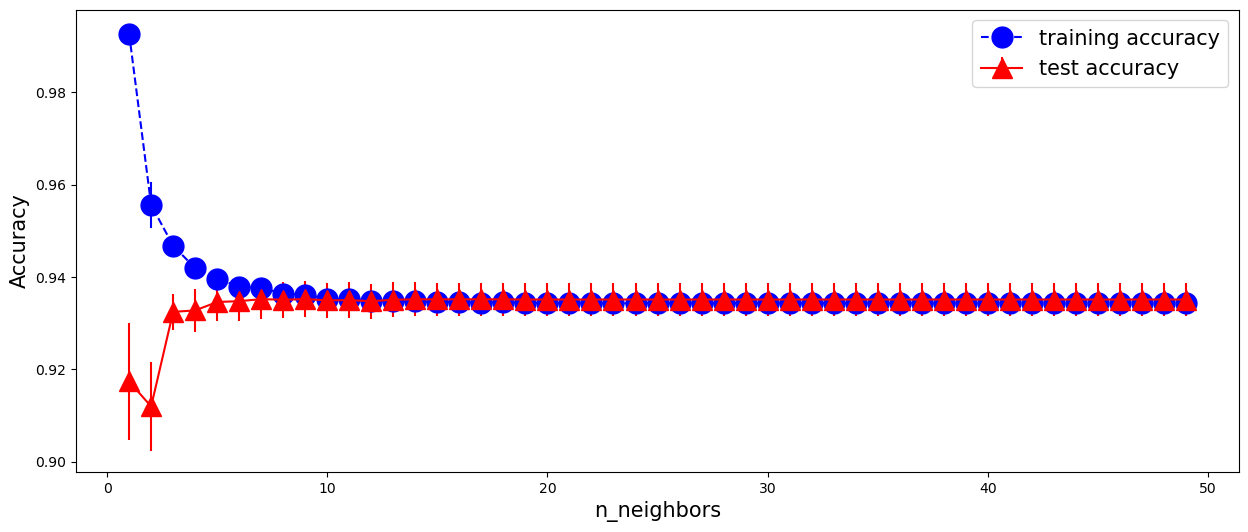

In [98]:
plot_hyperparameter_tuning(neighbors_settings, lahat_training_knn, lahat_test_knn, 'n_neighbors')

In [151]:
sum((y_cat2.value_counts() / len(y_cat2))**2)

0.34018626

# Regression, then binning

In [223]:
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

In [307]:
import tuner

import importlib
importlib.reload(tuner)

<module 'tuner' from '/home/bsdsba2028/qangos/ml1-project-lt4/working-notebooks/q/tuner.py'>

In [295]:
def bin_score(X, y, model, mapping_fn=round):
    """
    Evaluate a regression model, then bin outputs for classification-style accuracy.

    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        True continuous targets
    model : sklearn-like model
        Must implement .fit() and .predict()
    mapping_fn : function
        Function that maps continuous values → categorical bins
        Should work on numpy arrays

    Returns:
    --------
    dict with:
        - accuracy
        - mae
        - rmse
    """
    y_pred = model.predict(X)

    y_binned = y.apply(mapping_fn)
    y_pred_binned = pd.Series(y_pred).apply(mapping_fn)

    acc = accuracy_score(y_binned, y_pred_binned)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    return float(rmse)

In [154]:
sample_size = 1000

X_sample = X.iloc[:1000, :]
y_sample = y.iloc[:1000]

In [308]:
test_tuner = tuner.Tuner(X_sample, y_sample)

In [309]:
lasso_params = [1e-5, 1e-4, 1e-3, 7e-3, 1e-2, 5e-2, 0.1, 0.2,0.4, 0.75, 1, 1.5, 3, 10, 20, 100, 500]
test_tuner.tune(Lasso, 10, 0.25, 'alpha', lasso_params, {'max_iter': 100000}, bin_score, True)

In [296]:
bin_score(X_test_sample, y_test_sample, reg)

0.6796760289629088

In [313]:
test_tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17776854554,Lasso,alpha,0.001,0.5287,0.587457


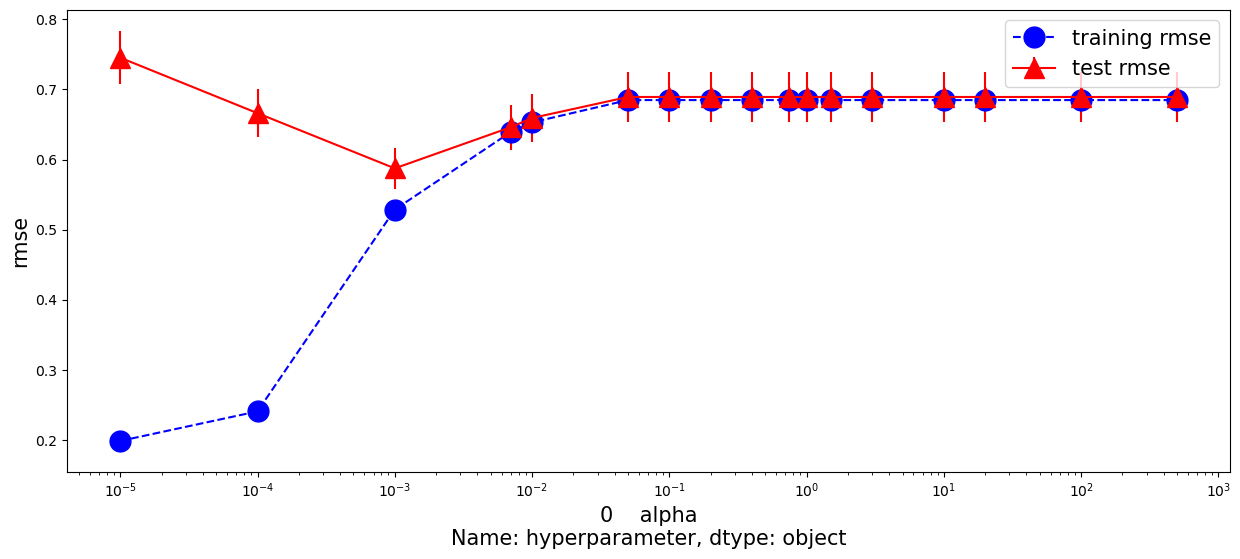

In [316]:
test_tuner.plot_hyperparameter_tuning(17776854554, True, metric_name='rmse')

In [162]:
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(X_sample, y_sample, test_size=0.25, random_state=42)

In [208]:
lasso_results = []

for i in lasso_params:
    reg = Lasso(alpha=i, max_iter=100000) # Define here wether Lasso or Ridge
    reg.fit(X_train_sample, y_train_sample)
    score = evaluate_regression_with_binning(X_test_sample, y_test_sample, reg, round)
    score['alpha'] = i
    lasso_results.append(score)

lasso_results = pd.DataFrame(lasso_results)

In [214]:
knn_results = []
neighbors = range(1,50)
for n in neighbors:
    reg = KNeighborsRegressor(n_neighbors=n)
    reg.fit(X_train_sample, y_train_sample)
    score = evaluate_regression_with_binning(X_test_sample, y_test_sample, reg, round)
    score['alpha'] = n
    knn_results.append(score)

knn_results = pd.DataFrame(knn_results)

In [224]:
ridge_results = []

for i in lasso_params:
    reg = Ridge(alpha=i, max_iter=100000) # Define here wether Lasso or Ridge
    reg.fit(X_train_sample, y_train_sample)
    score = evaluate_regression_with_binning(X_test_sample, y_test_sample, reg, round)
    score['alpha'] = i
    ridge_results.append(score)

ridge_results = pd.DataFrame(ridge_results)

In [215]:
def plot_hyperparam_custom_metric(results, log=False):
    hyperparameter = results['alpha']
    accuracy = results['accuracy']
    rmse = results['rmse']
    mae = results['mae']
    
    hparam_name = 'alpha'

    fig = plt.figure(figsize=(15, 6))
    if log:
        plt.xscale('log')
    params = {'legend.fontsize': 15, 'legend.handlelength': 2}
    plot.rcParams.update(params)
    
    plt.plot(hyperparameter, accuracy, label="accuracy", color='blue', marker='o', linestyle='-', markersize=15)
    plt.plot(hyperparameter, rmse, label="rmse", color='red', marker='^', linestyle='-', markersize=15)
    plt.plot(hyperparameter, mae, label="mae", color='orange', marker='x', linestyle='-', markersize=15)
    
    plt.ylabel("Performance", fontsize=15)
    plt.xlabel(hparam_name,fontsize=15)
    plt.legend()
    plt.ylim((0,1))
    pass

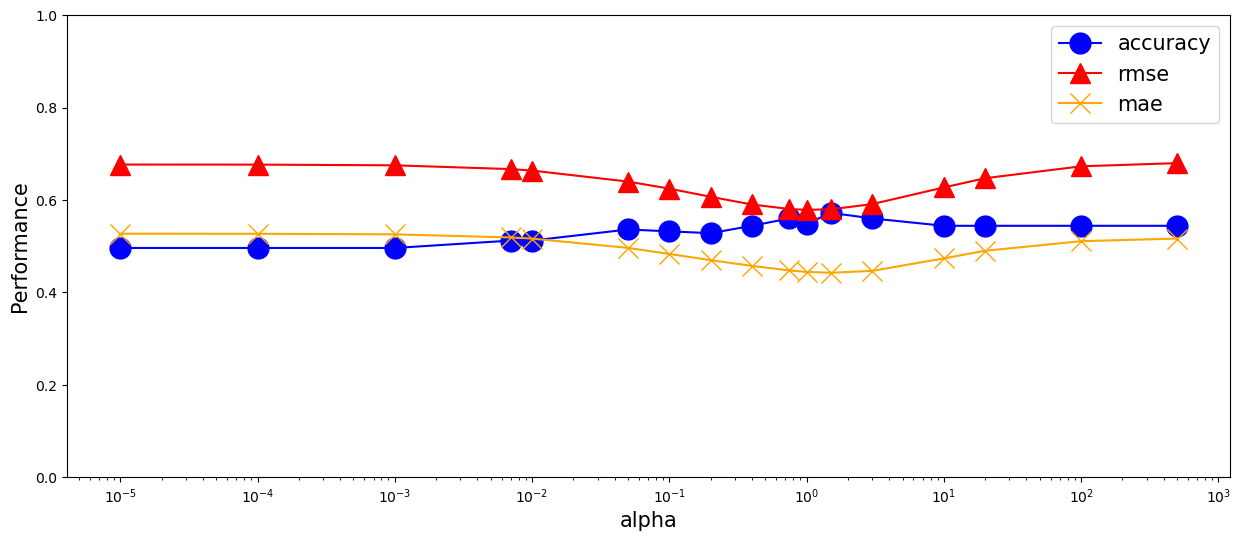

In [311]:
plot_hyperparam_custom_metric(ridge_results, True)

In [227]:
ridge_results.sort_values(by='rmse')

,accuracy,mae,rmse,alpha
10,0.548,0.444149,0.578556,1.00000
11,0.572,0.442334,0.579624,1.50000
9,0.560,0.447360,0.580295,0.75000
8,0.544,0.457233,0.590117,0.40000
12,0.560,0.446375,0.590843,3.00000
7,0.528,0.469594,0.606766,0.20000
6,0.532,0.483096,0.624416,0.10000
13,0.544,0.473448,0.627014,10.00000
5,0.536,0.496141,0.639748,0.05000
14,0.544,0.489957,0.647016,20.00000


In [230]:
y_baseline_sample = np.full_like(y_sample, fill_value=np.mean(y_sample))

mae_baseline_sample = mean_absolute_error(y_sample, y_baseline_sample)
rmse_baseline_sample = np.sqrt(mean_squared_error(y_sample, y_baseline_sample))

In [231]:
rmse_baseline_sample

np.float64(0.6860326301277513)

In [199]:
y_baseline = np.full_like(y, fill_value=np.mean(y))

mae_baseline = mean_absolute_error(y, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y, y_baseline))

In [245]:
def score(baseline, results):
    best_rmse = results.sort_values(by='rmse')['rmse'].reset_index(drop=True)[0]
    return {'param': results.sort_values(by='rmse').reset_index(drop=True)['alpha'][0],
            'rmse': best_rmse,
            'delta': baseline - best_rmse,
            'percent': 100*((baseline - best_rmse) / baseline)
           }

In [310]:
score(rmse_baseline_sample, lasso_results)

{'param': np.float64(0.001),
 'rmse': np.float64(0.578921163358523),
 'delta': np.float64(0.10711146676922834),
 'percent': np.float64(15.613173785812828)}